# Target Variable Engineering — `transition_next_12m` & `transition_direction`

This notebook constructs two supervised learning target variables from the same composite transition score.

## Design

**Definition:** A ZIP's transition direction is determined by whether it shows a meaningful departure from its own recent baseline across three signals over the following 12 months:

| Signal | Direction | What it captures |
|---|---|---|
| `home_value_yoy_pct` | Higher than usual | Sustained price appreciation |
| `inventory_mom_pct` | Lower than usual (tightening) | Supply pressure |
| `pct_sold_above_list` | Higher than usual | Market competitiveness / demand heat |

**Method:**
1. For each row at month `t`, compute the forward 12-month average of each signal (`t+1` to `t+12`)
2. Subtract the ZIP's own trailing 12-month average of each signal (`t-12` to `t-1`) → **delta**
3. Z-score each delta across all ZIP-month observations
4. Average the three z-scores into a **composite transition score** (inventory negated — falling inventory = positive signal)
5. Apply two thresholds to produce both targets:

| Target | Type | Definition |
|---|---|---|
| `transition_next_12m` | Binary | 1 if composite score ≥ 75th percentile (upward transition), else 0 |
| `transition_direction` | 3-class | `1` (up, ≥ p75) / `0` (stable, p25–p75) / `-1` (down, ≤ p25) |

**Why delta instead of raw forward value?**  
A delta measures *change from each ZIP's own norm*, not absolute level. This detects ZIPs *about to start* heating up or cooling down, not ones already at extreme levels.

**Label availability:**  
- Labels available: rows where a full 12-month forward window exists → Jan 2018 – Dec 2021  
- No label possible: Jan 2022 – Dec 2022 → prediction-only rows

Input:  `data/processed/features_engineered.csv`  
Output: `data/processed/modeling_dataset.csv` (labeled rows only, complete features)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi'] = 120

INPUT_PATH  = '../data/processed/features_engineered.csv'
OUTPUT_PATH = '../data/processed/modeling_dataset.csv'

---
## 1. Load Data

In [2]:
df = pd.read_csv(INPUT_PATH)
df['month'] = pd.to_datetime(df['month'])
df['zip']   = df['zip'].astype(str).str.zfill(5)
df = df.sort_values(['zip', 'month']).reset_index(drop=True)

print(f'Shape: {df.shape}')
print(f'ZIPs: {df["zip"].nunique()}')
print(f'Date range: {df["month"].min().date()} → {df["month"].max().date()}')

Shape: (55944, 68)
ZIPs: 666
Date range: 2018-01-31 → 2024-12-31


---
## 1b. Annual Data YoY Growth Rate Features

The ACS, CBP, and IRS datasets are annual — each month within a year carries the same repeated value for a given ZIP.  
**Year-over-year % change** transforms these static levels into dynamic signals that show *how fast* the neighborhood's fundamentals are improving or deteriorating.

These four features are the highest-signal choices for explaining *why* transitions happen:

| Feature | Signal |
|---|---|
| `business_establishments_yoy_pct` | Local business growth — new businesses signal improving neighborhood |
| `total_employment_yoy_pct` | Job base growth — economic vitality driver |
| `median_household_income_yoy_pct` | Rising incomes → affordability pressure on housing |
| `median_gross_rent_yoy_pct` | Rent inflation → early gentrification signal |

**Method:** `pct_change(12)` within each ZIP — compares the current month's annual value to the same month 12 periods ago (which carries the prior year's annual value). For Jun 2020 this gives `(ACS_2020 - ACS_2019) / ACS_2019`, exactly as intended.

In [3]:
ANNUAL_YOY_COLS = {
    'business_establishments': 'business_establishments_yoy_pct',
    'total_employment'        : 'total_employment_yoy_pct',
    'median_household_income' : 'median_household_income_yoy_pct',
    'median_gross_rent'       : 'median_gross_rent_yoy_pct',
}

for src_col, new_col in ANNUAL_YOY_COLS.items():
    df[new_col] = df.groupby('zip')[src_col].transform(
        lambda s: s.pct_change(12)
    )

# Validation: check NaN pattern and value range on the modeling window (Jun 2019–Dec 2021)
model_window = df[df['month'].between('2019-06-01', '2021-12-31')]
print('YoY growth features — NaN counts in modeling window (Jun 2019–Dec 2021):')
for col in ANNUAL_YOY_COLS.values():
    n_nan = model_window[col].isna().sum()
    pct_nan = n_nan / len(model_window) * 100
    print(f'  {col:<45}  NaN: {n_nan:,} ({pct_nan:.1f}%)')

print()
print('Summary statistics (model window):')
model_window[list(ANNUAL_YOY_COLS.values())].describe().round(4)

YoY growth features — NaN counts in modeling window (Jun 2019–Dec 2021):
  business_establishments_yoy_pct                NaN: 0 (0.0%)
  total_employment_yoy_pct                       NaN: 0 (0.0%)
  median_household_income_yoy_pct                NaN: 0 (0.0%)
  median_gross_rent_yoy_pct                      NaN: 155 (0.8%)

Summary statistics (model window):


C:\Users\tjgon\AppData\Local\Temp\ipykernel_151996\3089470000.py:10: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  lambda s: s.pct_change(12)


,business_establishments_yoy_pct,total_employment_yoy_pct,median_household_income_yoy_pct,median_gross_rent_yoy_pct
count,20646.0000,20646.0000,20646.0000,20491.0000
mean,0.0217,0.0111,0.0504,0.0415
std,0.0529,0.1026,0.0852,0.1624
min,-0.3500,-0.5512,-0.6064,-0.4554
25%,-0.0038,-0.0310,0.0104,0.0000
50%,0.0181,0.0059,0.0444,0.0345
75%,0.0431,0.0442,0.0823,0.0646
max,0.5000,1.3400,1.2404,5.5397


---
## 2. Forward and Trailing Signal Functions

**Forward 12-month mean at time `t`:**  
`s.rolling(12, min_periods=12).mean().shift(-12)` within each ZIP.  
At position `t`, `rolling(12).mean()` at position `t+12` = mean of `s[t+1]` through `s[t+12]`. The `shift(-12)` brings that value back to position `t`.

**Trailing 12-month mean at time `t`:**  
`s.rolling(12, min_periods=12).mean().shift(1)` within each ZIP.  
At position `t`, `rolling(12).mean()` at position `t-1` = mean of `s[t-12]` through `s[t-1]`.

In [4]:
def forward_12m_mean(col):
    """Mean of next 12 months (t+1 to t+12) within each ZIP."""
    return (
        df.groupby('zip')[col]
        .transform(lambda s: s.rolling(12, min_periods=12).mean().shift(-12))
    )

def trailing_12m_mean(col):
    """Mean of prior 12 months (t-12 to t-1) within each ZIP."""
    return (
        df.groupby('zip')[col]
        .transform(lambda s: s.rolling(12, min_periods=12).mean().shift(1))
    )

---
## 3. Compute Forward Signals, Trailing Baselines, and Deltas

In [5]:
SIGNALS = {
    'price'          : 'home_value_yoy_pct',
    'inventory'      : 'inventory_mom_pct',
    'competitiveness': 'pct_sold_above_list',
}

for name, col in SIGNALS.items():
    df[f'fwd_{name}']      = forward_12m_mean(col)
    df[f'trailing_{name}'] = trailing_12m_mean(col)
    df[f'delta_{name}']    = df[f'fwd_{name}'] - df[f'trailing_{name}']

# Rows with at least one valid delta (both forward and trailing available)
delta_cols = ['delta_price', 'delta_inventory', 'delta_competitiveness']
valid_mask = df[delta_cols].notna().all(axis=1)

print(f'Rows with valid deltas: {valid_mask.sum():,} / {len(df):,}')
print(f'Date range of valid rows: {df.loc[valid_mask, "month"].min().date()} → {df.loc[valid_mask, "month"].max().date()}')
print()
print('Delta summary (valid rows only):')
df.loc[valid_mask, delta_cols].describe().round(4)

Rows with valid deltas: 39,960 / 55,944
Date range of valid rows: 2019-01-31 → 2023-12-31

Delta summary (valid rows only):


,delta_price,delta_inventory,delta_competitiveness
count,39960.0000,39960.0000,39960.0000
mean,-0.0039,0.0070,0.0066
std,0.0844,0.0827,0.1365
min,-0.3348,-0.6766,-0.6315
25%,-0.0556,-0.0328,-0.0826
50%,-0.0000,0.0032,0.0062
75%,0.0509,0.0424,0.0985
max,0.3423,1.1005,0.6596


---
## 4. Z-Score the Deltas and Build Composite Score

Z-scores are computed across all valid ZIP-month rows so that each delta is on a common scale.  
Inventory is **negated** — a negative inventory delta (inventory falling more than usual) is a *positive* transition signal.

In [6]:
def zscore(series):
    return (series - series.mean()) / series.std()

# Compute z-scores on valid rows only, assign back to full df
valid_idx = df[valid_mask].index

df.loc[valid_idx, 'z_price']           =  zscore(df.loc[valid_idx, 'delta_price'])
df.loc[valid_idx, 'z_inventory']       = -zscore(df.loc[valid_idx, 'delta_inventory'])  # negated
df.loc[valid_idx, 'z_competitiveness'] =  zscore(df.loc[valid_idx, 'delta_competitiveness'])

# Composite = equal-weight average of the three z-scores
df.loc[valid_idx, 'transition_score'] = (
    df.loc[valid_idx, ['z_price', 'z_inventory', 'z_competitiveness']].mean(axis=1)
)

score_valid = df.loc[valid_idx, 'transition_score']
print('Composite transition score summary:')
print(score_valid.describe().round(4))

Composite transition score summary:
count   39960.0000
mean        0.0000
std         0.6643
min        -4.3923
25%        -0.4730
50%         0.0412
75%         0.4767
max         3.1659
Name: transition_score, dtype: float64


---
## 5. Score Distribution and Threshold Selection

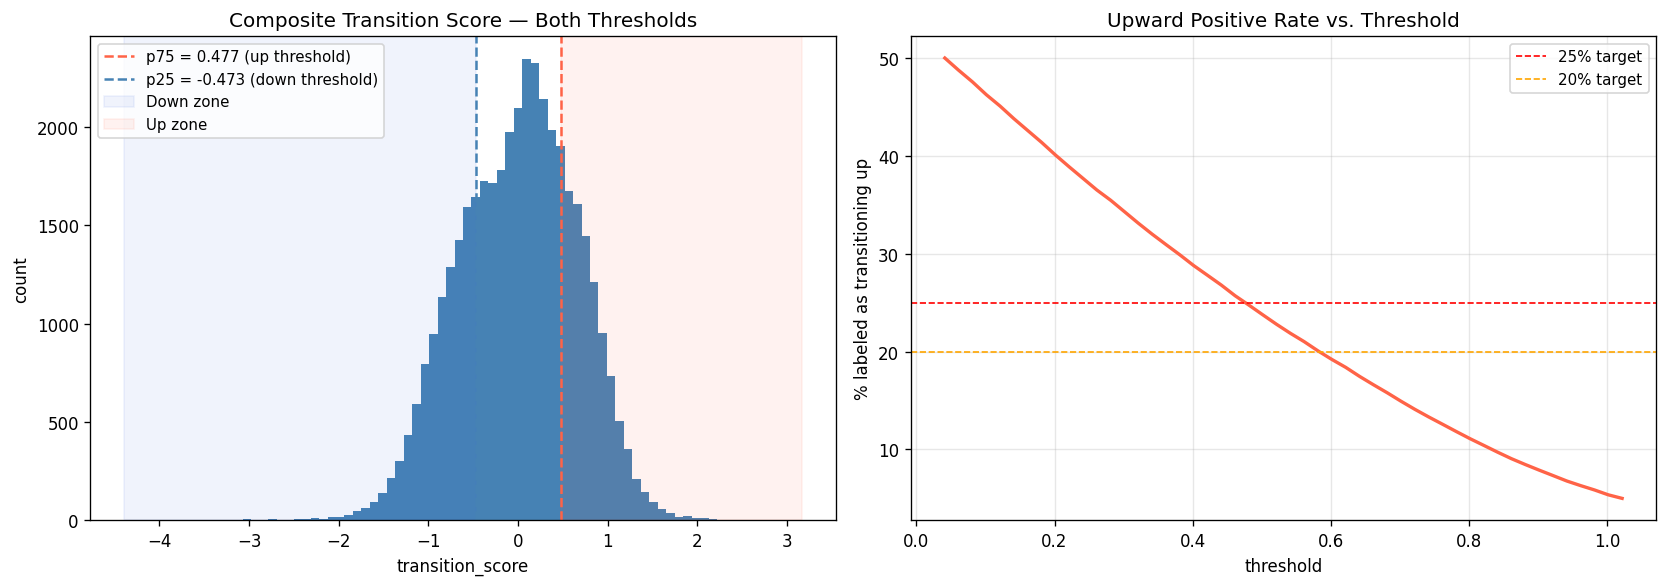

Threshold summary:
  p25 = -0.473
  p70 = 0.380
  p75 = 0.477
  p80 = 0.583


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of composite score with both thresholds
p25_val = score_valid.quantile(0.25)
p75_val = score_valid.quantile(0.75)

axes[0].hist(score_valid, bins=80, color='steelblue', edgecolor='none')
axes[0].axvline(p75_val, color='tomato',    linestyle='--', linewidth=1.5, label=f'p75 = {p75_val:.3f} (up threshold)')
axes[0].axvline(p25_val, color='steelblue', linestyle='--', linewidth=1.5, label=f'p25 = {p25_val:.3f} (down threshold)')
axes[0].axvspan(score_valid.min(), p25_val, alpha=0.08, color='royalblue', label='Down zone')
axes[0].axvspan(p75_val, score_valid.max(), alpha=0.08, color='tomato',    label='Up zone')
axes[0].set_title('Composite Transition Score — Both Thresholds')
axes[0].set_xlabel('transition_score')
axes[0].set_ylabel('count')
axes[0].legend(fontsize=9)

# Positive rate for upward class at different thresholds
thresholds = np.linspace(score_valid.quantile(0.50), score_valid.quantile(0.95), 50)
pos_rates  = [((score_valid >= t).mean() * 100) for t in thresholds]
axes[1].plot(thresholds, pos_rates, color='tomato', linewidth=2)
axes[1].axhline(25, color='red',    linestyle='--', linewidth=1, label='25% target')
axes[1].axhline(20, color='orange', linestyle='--', linewidth=1, label='20% target')
axes[1].set_title('Upward Positive Rate vs. Threshold')
axes[1].set_xlabel('threshold')
axes[1].set_ylabel('% labeled as transitioning up')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print exact percentile values
print('Threshold summary:')
for pct in [25, 70, 75, 80]:
    t = score_valid.quantile(pct / 100)
    up   = (score_valid >= t).mean() * 100
    down = (score_valid <= score_valid.quantile((100 - pct) / 100)).mean() * 100
    print(f'  p{pct} = {t:.3f}')

---
## 6. Create Labels

Two targets are created from the same composite score using symmetric percentile thresholds:

- **`transition_next_12m`** (binary): `1` if score ≥ p75 (upward transition), `0` otherwise — used for binary classification
- **`transition_direction`** (3-class): `1` (up) / `0` (stable) / `-1` (down) — used for ordinal / multi-class modeling

The p25/p75 thresholds produce a roughly 25% / 50% / 25% class split.

In [8]:
LOWER_PERCENTILE = 25
UPPER_PERCENTILE = 75

# Identify which valid rows will also survive the lag-feature completeness filter.
# Thresholds must be computed on this final subset so that the p25/p75 split
# produces symmetric class sizes in the actual modeling dataset.
FEATURE_COLS_PREVIEW = [
    c for c in df.columns
    if c not in ['zip', 'month', 'transition_next_12m', 'transition_direction',
                 'fwd_price', 'fwd_inventory', 'fwd_competitiveness',
                 'trailing_price', 'trailing_inventory', 'trailing_competitiveness',
                 'delta_price', 'delta_inventory', 'delta_competitiveness',
                 'z_price', 'z_inventory', 'z_competitiveness',
                 'transition_score']
]

# Rows that have a valid composite score AND complete engineered features
final_mask = valid_mask & df[FEATURE_COLS_PREVIEW].notna().all(axis=1)
final_idx  = df[final_mask].index
score_final = df.loc[final_idx, 'transition_score']

print(f'Valid-score rows:  {valid_mask.sum():,}')
print(f'Complete-feature rows with score: {len(final_idx):,}  ← thresholds computed here')

lower_thresh = score_final.quantile(LOWER_PERCENTILE / 100)
upper_thresh = score_final.quantile(UPPER_PERCENTILE / 100)

# Binary: 1 = upward transition (score >= p75)
df.loc[valid_idx, 'transition_next_12m'] = (
    (df.loc[valid_idx, 'transition_score'] >= upper_thresh).astype(int)
)

# 3-class: 1 = up, -1 = down, 0 = stable
df.loc[valid_idx, 'transition_direction'] = 0
df.loc[valid_idx[df.loc[valid_idx, 'transition_score'] >= upper_thresh], 'transition_direction'] =  1
df.loc[valid_idx[df.loc[valid_idx, 'transition_score'] <= lower_thresh], 'transition_direction'] = -1

# --- Summary on the final modeling subset ---
binary_counts = df.loc[final_idx, 'transition_next_12m'].value_counts().sort_index()
dir_counts    = df.loc[final_idx, 'transition_direction'].value_counts().sort_index()
n = len(final_idx)

print(f'\nThresholds: lower (p{LOWER_PERCENTILE}) = {lower_thresh:.4f},  upper (p{UPPER_PERCENTILE}) = {upper_thresh:.4f}')
print()
print('transition_next_12m (binary) — in final modeling rows:')
print(f'  0 (not transitioning up): {binary_counts[0]:,} ({binary_counts[0]/n:.1%})')
print(f'  1 (transitioning up):     {binary_counts[1]:,} ({binary_counts[1]/n:.1%})')
print()
print('transition_direction (3-class) — in final modeling rows:')
for label, name in [(-1, 'down'), (0, 'stable'), (1, 'up')]:
    cnt = dir_counts.get(label, 0)
    print(f'  {label:+d} ({name}):    {cnt:,} ({cnt/n:.1%})')

Valid-score rows:  39,960
Complete-feature rows with score: 36,025  ← thresholds computed here

Thresholds: lower (p25) = -0.5173,  upper (p75) = 0.5091

transition_next_12m (binary) — in final modeling rows:
  0 (not transitioning up): 27,018 (75.0%)
  1 (transitioning up):     9,007 (25.0%)

transition_direction (3-class) — in final modeling rows:
  -1 (down):    9,007 (25.0%)
  +0 (stable):    18,011 (50.0%)
  +1 (up):    9,007 (25.0%)


---
## 7. Label Validation

Before using this label for modeling, we need to sanity-check it.  
If the label is well-constructed, ZIPs labeled `1` should look measurably different from ZIPs labeled `0` on the signals that define them.

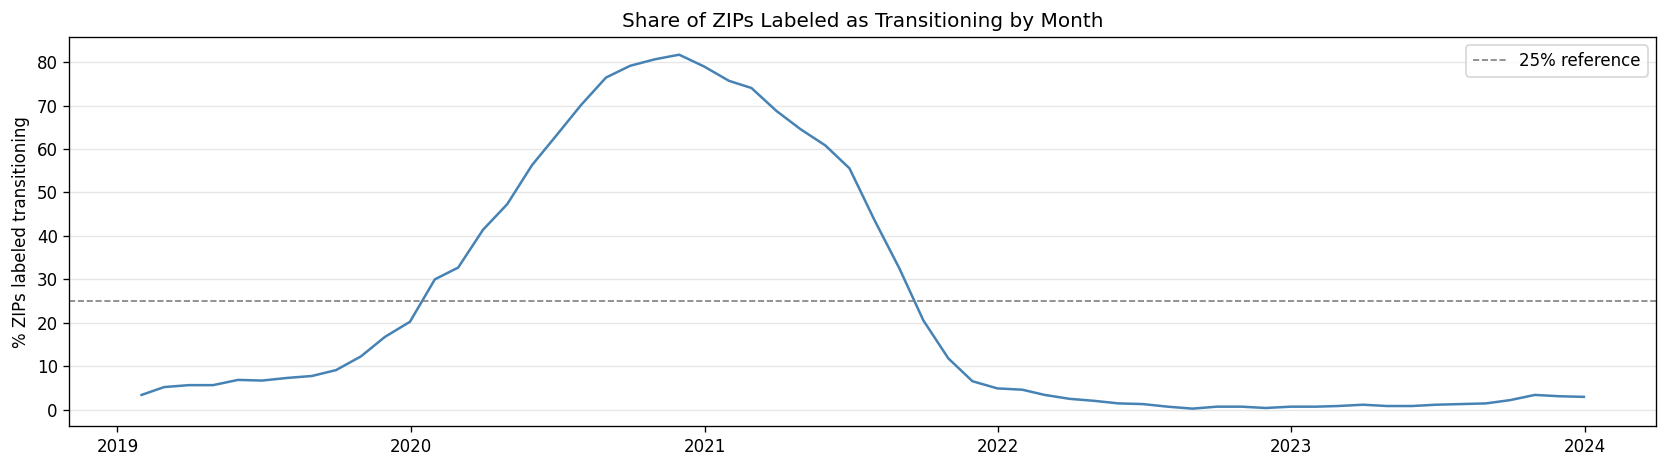

In [9]:
# --- 7a. Temporal distribution: % transitioning by month ---
# Expect a spike around 2020-2022 (COVID housing boom)

temp = (
    df.loc[valid_idx]
    .groupby('month')['transition_next_12m']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'pct_transitioning', 'count': 'n_zips'})
)
temp['pct_transitioning'] *= 100

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(temp.index, temp['pct_transitioning'], color='steelblue', linewidth=1.5)
ax.axhline(25, color='grey', linestyle='--', linewidth=1, label='25% reference')
ax.set_ylabel('% ZIPs labeled transitioning')
ax.set_title('Share of ZIPs Labeled as Transitioning by Month')
ax.grid(axis='y', alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

In [10]:
# --- 7b. Signal means by transition_direction (3-class) ---
# Up ZIPs should show highest price growth, most tightening, highest competitiveness
# Down ZIPs should show the opposite

check_cols = {
    'fwd_price'          : 'Fwd 12m avg home_value_yoy_pct',
    'fwd_inventory'      : 'Fwd 12m avg inventory_mom_pct (↓ = tightening)',
    'fwd_competitiveness': 'Fwd 12m avg pct_sold_above_list',
    'delta_price'        : 'Δ price growth vs trailing baseline',
    'delta_inventory'    : 'Δ inventory vs trailing baseline (↓ = more tightening)',
    'delta_competitiveness': 'Δ competitiveness vs trailing baseline',
}

labeled = df.loc[valid_idx].copy()
group_means = (
    labeled
    .groupby('transition_direction')[list(check_cols.keys())]
    .mean()
    .T
    .rename(columns={-1: 'Down (-1)', 0: 'Stable (0)', 1: 'Up (+1)'})
    .round(4)
)
group_means.index = list(check_cols.values())

print('Mean signal values by transition_direction:')
group_means

Mean signal values by transition_direction:


transition_direction,Down (-1),Stable (0),Up (+1)
Fwd 12m avg home_value_yoy_pct,0.0716,0.0949,0.1542
Fwd 12m avg inventory_mom_pct (↓ = tightening),0.0602,0.0188,-0.0064
Fwd 12m avg pct_sold_above_list,0.2494,0.2660,0.3928
Δ price growth vs trailing baseline,-0.0992,-0.0011,0.0837
Δ inventory vs trailing baseline (↓ = more tightening),0.0502,0.0032,-0.0267
Δ competitiveness vs trailing baseline,-0.1357,0.0033,0.1548


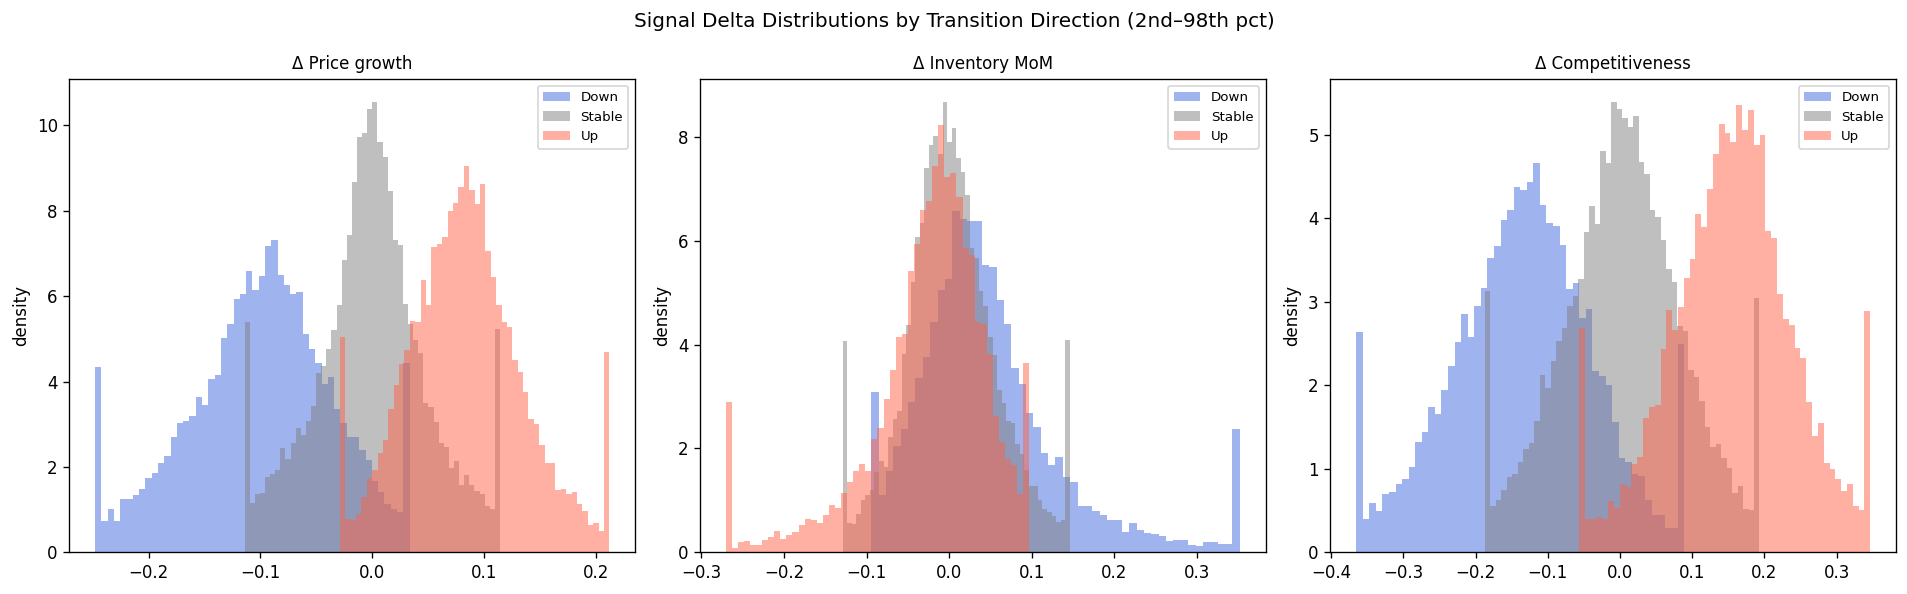

In [11]:
# --- 7c. Distribution of each signal component by transition_direction ---

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors = {-1: 'royalblue', 0: 'grey', 1: 'tomato'}
labels = {-1: 'Down', 0: 'Stable', 1: 'Up'}

for i, (col, label_text) in enumerate([
    ('delta_price',           'Δ Price growth'),
    ('delta_inventory',       'Δ Inventory MoM'),
    ('delta_competitiveness', 'Δ Competitiveness'),
]):
    for grp in [-1, 0, 1]:
        data = labeled[labeled['transition_direction'] == grp][col].dropna()
        low, high = data.quantile(0.02), data.quantile(0.98)
        axes[i].hist(data.clip(low, high), bins=50, alpha=0.5,
                     color=colors[grp], label=labels[grp], density=True)
    axes[i].set_title(label_text, fontsize=10)
    axes[i].legend(fontsize=8)
    axes[i].set_ylabel('density')

plt.suptitle('Signal Delta Distributions by Transition Direction (2nd–98th pct)', fontsize=12)
plt.tight_layout()
plt.show()

In [12]:
# --- 7d. Top and bottom transitioning ZIPs ---

zip_stats = (
    labeled
    .groupby('zip')['transition_direction']
    .agg(
        up_rate   = lambda x: (x ==  1).mean(),
        down_rate = lambda x: (x == -1).mean(),
        stable_rate = lambda x: (x == 0).mean(),
        total_months = 'count',
    )
    .round(3)
    .sort_values('up_rate', ascending=False)
)

print('Top 15 ZIPs by upward transition rate:')
print(zip_stats.head(15).to_string())
print()
print('Top 15 ZIPs by downward transition rate:')
print(zip_stats.sort_values('down_rate', ascending=False).head(15).to_string())

Top 15 ZIPs by upward transition rate:
       up_rate  down_rate  stable_rate  total_months
zip                                                 
28303   0.4170     0.2830       0.3000            60
28314   0.4170     0.3000       0.2830            60
27916   0.4170     0.2670       0.3170            60
27927   0.4000     0.3000       0.3000            60
28594   0.4000     0.3000       0.3000            60
27950   0.4000     0.3670       0.2330            60
27283   0.4000     0.2830       0.3170            60
27522   0.4000     0.3500       0.2500            60
28634   0.4000     0.3500       0.2500            60
29055   0.3830     0.4170       0.2000            60
27505   0.3830     0.2670       0.3500            60
28348   0.3830     0.2330       0.3830            60
28306   0.3830     0.2330       0.3830            60
27231   0.3830     0.2500       0.3670            60
28304   0.3830     0.2500       0.3670            60

Top 15 ZIPs by downward transition rate:
       up_rate  do

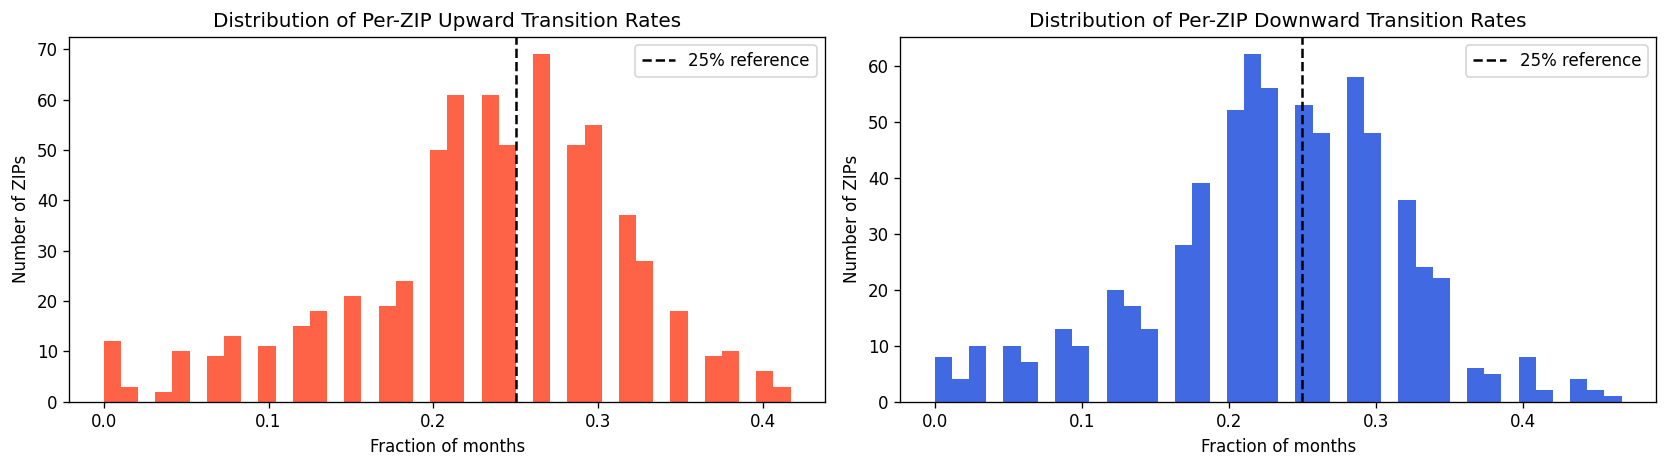

ZIPs never going up   (up_rate = 0):   12
ZIPs never going down (down_rate = 0): 8
ZIPs always up   (up_rate = 1):   0
ZIPs always down (down_rate = 1): 0


In [13]:
# --- 7e. Distribution of per-ZIP up/down rates ---

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, col, color, title in [
    (axes[0], 'up_rate',   'tomato',    'Distribution of Per-ZIP Upward Transition Rates'),
    (axes[1], 'down_rate', 'royalblue', 'Distribution of Per-ZIP Downward Transition Rates'),
]:
    ax.hist(zip_stats[col], bins=40, color=color, edgecolor='none')
    ax.axvline(0.25, color='black', linestyle='--', linewidth=1.5, label='25% reference')
    ax.set_xlabel('Fraction of months')
    ax.set_ylabel('Number of ZIPs')
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()

print(f'ZIPs never going up   (up_rate = 0):   {(zip_stats["up_rate"]   == 0).sum()}')
print(f'ZIPs never going down (down_rate = 0): {(zip_stats["down_rate"] == 0).sum()}')
print(f'ZIPs always up   (up_rate = 1):   {(zip_stats["up_rate"]   == 1).sum()}')
print(f'ZIPs always down (down_rate = 1): {(zip_stats["down_rate"] == 1).sum()}')

In [14]:
# --- 7f. Component contribution check ---
# Are all three signals contributing meaningfully, or is one dominating?

z_corr = labeled[['z_price', 'z_inventory', 'z_competitiveness', 'transition_score']].corr().round(3)

print('Correlation between z-score components and composite score:')
print(z_corr)
print()
print('Variance of each z-score component (should all be ~1.0 if well-standardized):')
print(labeled[['z_price', 'z_inventory', 'z_competitiveness']].var().round(3))

Correlation between z-score components and composite score:
                   z_price  z_inventory  z_competitiveness  transition_score
z_price             1.0000      -0.0580             0.6260            0.7870
z_inventory        -0.0580       1.0000            -0.0820            0.4310
z_competitiveness   0.6260      -0.0820             1.0000            0.7750
transition_score    0.7870       0.4310             0.7750            1.0000

Variance of each z-score component (should all be ~1.0 if well-standardized):
z_price             1.0000
z_inventory         1.0000
z_competitiveness   1.0000
dtype: float64


---
## 8. Build Final Modeling Dataset

Keep only:
- Rows that have valid labels (`transition_next_12m` and `transition_direction` are not NaN)
- Rows that have a complete engineered feature set (no NaNs in any feature column)

Drop the intermediate columns used to build the labels — they are not model features  
(forward signals, trailing baselines, deltas, z-scores, and composite score).

In [15]:
LABEL_CONSTRUCTION_COLS = [
    'fwd_price', 'fwd_inventory', 'fwd_competitiveness',
    'trailing_price', 'trailing_inventory', 'trailing_competitiveness',
    'delta_price', 'delta_inventory', 'delta_competitiveness',
    'z_price', 'z_inventory', 'z_competitiveness',
    'transition_score',
]

LABEL_COLS = ['transition_next_12m', 'transition_direction']

# All feature columns (everything except keys, labels, and construction cols)
FEATURE_COLS = [
    c for c in df.columns
    if c not in ['zip', 'month'] + LABEL_COLS + LABEL_CONSTRUCTION_COLS
]

# Keep rows with both labels + complete features
modeling_df = (
    df[df[LABEL_COLS].notna().all(axis=1)]
    .dropna(subset=FEATURE_COLS)
    .copy()
)

# Drop construction columns
modeling_df = modeling_df.drop(columns=LABEL_CONSTRUCTION_COLS)

print(f'Full dataset:         {len(df):,} rows')
print(f'Rows with labels:     {df[LABEL_COLS].notna().all(axis=1).sum():,}')
print(f'Final modeling rows:  {len(modeling_df):,} (labels + complete features)')
print(f'Date range:           {modeling_df["month"].min().date()} → {modeling_df["month"].max().date()}')
print(f'ZIPs represented:     {modeling_df["zip"].nunique()}')
print(f'Feature columns:      {len(FEATURE_COLS)}')
print()

binary_dist = modeling_df['transition_next_12m'].value_counts().sort_index()
dir_dist    = modeling_df['transition_direction'].value_counts().sort_index()
n = len(modeling_df)

print('transition_next_12m:')
print(f'  0: {binary_dist[0]:,} ({binary_dist[0]/n:.1%})')
print(f'  1: {binary_dist[1]:,} ({binary_dist[1]/n:.1%})')
print()
print('transition_direction:')
for label, name in [(-1, 'down'), (0, 'stable'), (1, 'up')]:
    cnt = dir_dist.get(label, 0)
    print(f'  {label:+d} ({name}): {cnt:,} ({cnt/n:.1%})')

Full dataset:         55,944 rows
Rows with labels:     39,960
Final modeling rows:  36,025 (labels + complete features)
Date range:           2019-06-30 → 2023-12-31
ZIPs represented:     655
Feature columns:      70

transition_next_12m:
  0: 27,018 (75.0%)
  1: 9,007 (25.0%)

transition_direction:
  -1 (down): 9,007 (25.0%)
  +0 (stable): 18,011 (50.0%)
  +1 (up): 9,007 (25.0%)


In [16]:
# Final check: no NaNs in features or label
total_missing = modeling_df.drop(columns=['zip', 'month']).isna().sum().sum()
print(f'Missing values in final modeling dataset: {total_missing}')
print(f'Final shape: {modeling_df.shape}')

Missing values in final modeling dataset: 0
Final shape: (36025, 74)


---
## 9. Save

In [17]:
# Column order: keys → features → labels
final_cols = ['zip', 'month'] + FEATURE_COLS + ['transition_next_12m', 'transition_direction']
modeling_df = modeling_df[final_cols]

modeling_df.to_csv(OUTPUT_PATH, index=False)
print(f'Saved: {OUTPUT_PATH}')
print(f'Shape: {modeling_df.shape}')
print(f'  {modeling_df["zip"].nunique()} ZIPs × {modeling_df["month"].nunique()} months')
print(f'  Targets: transition_next_12m (binary), transition_direction (3-class: -1/0/+1)')
modeling_df.head(3)

Saved: ../data/processed/modeling_dataset.csv
Shape: (36025, 74)
  655 ZIPs × 55 months
  Targets: transition_next_12m (binary), transition_direction (3-class: -1/0/+1)


,zip,month,home_value_index,median_sale_price,median_list_price,median_price_per_sqft,homes_sold,new_listings,inventory,median_days_on_market,avg_sale_to_list_ratio,pct_sold_above_list,pct_off_market_in_2wks,mortgage_rate_30yr,mortgage_arm_spread,median_household_income,median_owner_home_value,median_gross_rent,owner_occupancy_rate,business_establishments,total_employment,avg_pay_per_employee,tax_returns_filed,adjusted_gross_income,taxable_interest_income,home_value_mom_pct,home_value_yoy_pct,sale_price_mom_pct,sale_price_yoy_pct,inventory_mom_pct,inventory_yoy_pct,home_value_mom_3m_avg,sale_price_mom_3m_avg,inventory_mom_3m_avg,pct_above_list_3m_avg,sale_to_list_3m_avg,off_market_2wk_3m_avg,home_value_mom_12m_avg,sale_price_mom_12m_avg,inventory_mom_12m_avg,home_value_mom_3m_std,sale_price_mom_3m_std,home_value_accel,sale_price_accel,inventory_accel,price_to_income_ratio,rent_to_income_ratio,price_to_rent_ratio,home_value_vs_baseline,sale_price_vs_baseline,inventory_vs_baseline,dom_vs_baseline,home_value_mom_pct_lag3,home_value_mom_pct_lag6,sale_price_mom_pct_lag3,sale_price_mom_pct_lag6,inventory_mom_pct_lag3,inventory_mom_pct_lag6,pct_sold_above_list_lag3,pct_sold_above_list_lag6,avg_sale_to_list_ratio_lag3,avg_sale_to_list_ratio_lag6,home_value_vs_baseline_lag3,home_value_vs_baseline_lag6,sale_price_vs_baseline_lag3,sale_price_vs_baseline_lag6,inventory_vs_baseline_lag3,inventory_vs_baseline_lag6,business_establishments_yoy_pct,total_employment_yoy_pct,median_household_income_yoy_pct,median_gross_rent_yoy_pct,transition_next_12m,transition_direction
17,27006,2019-06-30,257308.6259,252000.0000,249950.0000,116.7134,87.0000,98.0000,117.0000,34.5000,0.9759,0.3448,0.4286,3.8025,0.3275,81411.0000,233600.0000,824.0000,0.9058,294.0000,3093.0000,35.7430,7200.0000,719427.0000,7893.0000,0.0017,0.0343,-0.0400,-0.0270,-0.0640,-0.1643,0.0024,-0.0140,-0.0342,0.2903,0.9729,0.4669,0.0028,-0.0015,-0.0133,0.0007,0.0226,-0.0004,-0.0125,-0.0208,3.1606,0.1215,26.0223,0.0146,-0.0055,-0.0416,-0.5730,0.0035,0.0025,-0.0436,0.0625,-0.0152,0.0360,0.2209,0.1778,0.9735,0.9565,0.0158,0.0143,0.0357,0.0234,0.0421,-0.0957,-0.0265,0.0397,0.0425,-0.0529,0.0000,0.0000
18,27006,2019-07-31,257769.7121,257000.0000,256250.0000,117.2237,90.0000,78.0000,93.0000,38.5000,0.9764,0.2444,0.3516,3.7650,0.3000,81411.0000,233600.0000,824.0000,0.9058,294.0000,3093.0000,35.7430,7200.0000,719427.0000,7893.0000,0.0018,0.0328,0.0198,0.0651,-0.2051,-0.2677,0.0020,-0.0074,-0.1025,0.2894,0.9748,0.4251,0.0027,0.0059,-0.0227,0.0004,0.0303,-0.0007,-0.0132,-0.0798,3.1663,0.1215,26.0689,0.0137,0.0091,-0.2201,-0.4962,0.0030,0.0032,0.0000,0.0200,0.0000,0.0609,0.2473,0.1765,0.9708,0.9643,0.0161,0.0147,0.0364,0.0301,0.0435,-0.0292,-0.0265,0.0397,0.0425,-0.0529,0.0000,0.0000
19,27006,2019-08-31,258656.1267,251000.0000,296500.0000,116.0000,85.0000,79.0000,89.0000,57.0000,0.9692,0.1765,0.2949,3.6160,0.2560,81411.0000,233600.0000,824.0000,0.9058,294.0000,3093.0000,35.7430,7200.0000,719427.0000,7893.0000,0.0034,0.0324,-0.0233,0.0458,-0.0430,-0.2992,0.0023,-0.0145,-0.1040,0.2552,0.9738,0.3584,0.0027,0.0044,-0.0263,0.0010,0.0309,-0.0004,-0.0189,-0.0778,3.1772,0.1215,26.1586,0.0145,-0.0180,-0.2333,-0.2214,0.0024,0.0028,-0.0019,0.0577,-0.0385,0.0820,0.2788,0.2364,0.9720,0.9731,0.0158,0.0149,0.0336,0.0837,0.0081,0.0581,-0.0265,0.0397,0.0425,-0.0529,0.0000,0.0000
